##### Copyright 2019 The TensorFlow Authors.

# DeepDream

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://www.tensorflow.org/tutorials/generative/deepdream"><img src="https://www.tensorflow.org/images/tf_logo_32px.png" />View on TensorFlow.org</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/generative/deepdream.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/tensorflow/docs/blob/master/site/en/tutorials/generative/deepdream.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
  <td>
    <a href="https://storage.googleapis.com/tensorflow_docs/docs/site/en/tutorials/generative/deepdream.ipynb"><img src="https://www.tensorflow.org/images/download_logo_32px.png" />Download notebook</a>
  </td>
</table>

Este tutorial contiene una implementación mínima de **DeepDream**, como se describe en este [post del blog](https://ai.googleblog.com/2015/06/inceptionism-going-deeper-into-neural.html) de Alexander Mordvintsev.

DeepDream es un experimento que **visualiza los patrones aprendidos por una red neuronal**. Similar a cuando un niño observa las nubes e intenta interpretar formas al azar, DeepDream **sobreinterpreta y realza los patrones que ve en una imagen**.

Lo hace pasando una imagen a través de la red neuronal y luego calculando el **gradiente de la imagen con respecto a las activaciones de una capa específica**. La imagen se modifica para **incrementar estas activaciones**, realzando los patrones que la red percibe y produciendo así una imagen con apariencia onírica.  
A este proceso se le llamó **“Inceptionism”** (una referencia a [InceptionNet](https://arxiv.org/pdf/1409.4842.pdf) y a la [película](https://es.wikipedia.org/wiki/Inception) *Inception*).

A continuación, vamos a demostrar **cómo hacer que una red neuronal “sueñe” y realce los patrones surrealistas que ve en una imagen**.

![Dogception](https://www.tensorflow.org/tutorials/generative/images/dogception.png)


## Instala las librerias y escoge una imagen

Saving 247986528_10159364232637211_7172664914991702913_n.jpg to 247986528_10159364232637211_7172664914991702913_n.jpg


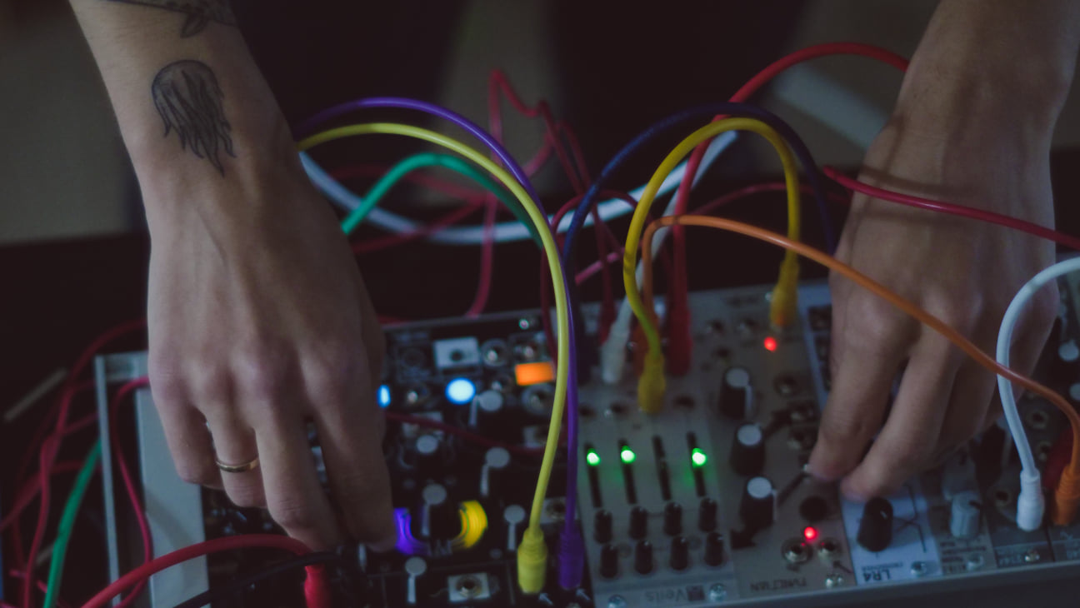

In [1]:
#@title Cargar modelo DeepDream
# Importar librerías necesarias
import tensorflow as tf
import numpy as np
import matplotlib as mpl
import IPython.display as display
import PIL.Image
from google.colab import files
import PIL.Image
import numpy as np
import tensorflow as tf
from IPython import display

# --------------------------------------------------
# Función para subir una imagen desde tu PC
def upload_image(max_dim=None):
    """
    Abre un diálogo para subir una imagen desde tu computadora,
    la redimensiona si max_dim está definido y devuelve un array NumPy.
    """
    uploaded = files.upload()  # abrir selector de archivos
    # Tomar el primer archivo subido
    filename = list(uploaded.keys())[0]
    img = PIL.Image.open(filename)
    if max_dim:
        img.thumbnail((max_dim, max_dim))
    return np.array(img)

# --------------------------------------------------
# Función para normalizar una imagen (desprocesarla)
def deprocess(img):
    """
    Convierte la imagen desde rango [-1, 1] a valores de 0 a 255 (uint8)
    para poder mostrarla con PIL o Matplotlib.
    """
    img = 255 * (img + 1.0) / 2.0
    return tf.cast(img, tf.uint8)

# --------------------------------------------------
# Función para mostrar imagen
def show(img):
    display.display(PIL.Image.fromarray(np.array(img)))

# --------------------------------------------------
# Subir la imagen y mostrarla
original_img = upload_image(max_dim=1080)  # ajustá max_dim según prefieras
show(original_img)


## Prepara los modelos de extraccion de caracteristicas

**Descargar** y preparar un modelo de clasificación de imágenes preentrenado.  
Usaremos [InceptionV3](https://keras.io/api/applications/inceptionv3/), que es similar al modelo utilizado originalmente en DeepDream.  

Ten en cuenta que cualquier [modelo preentrenado](https://keras.io/api/applications/#available-models) funcionará, aunque **tendrás que ajustar los nombres de las capas** que se mencionan más abajo si decides usar otro modelo.


In [ ]:
base_model = tf.keras.applications.InceptionV3(include_top=False, weights='imagenet')


La idea de **DeepDream** es **elegir una capa (o varias capas) y maximizar la "pérdida" (loss)** de manera que la imagen **excite cada vez más esas capas**.  

La complejidad de los patrones incorporados depende de las capas que elijas:  
- **Capas bajas** producen trazos o patrones simples.  
- **Capas profundas** generan características más sofisticadas en las imágenes, o incluso **objetos completos**.

La idea de DeepDream es elegir una capa (o varias capas) y maximizar la "pérdida" (loss) de manera que la imagen excite cada vez más esas capas.

La complejidad de los patrones incorporados depende de las capas que elijas:

Capas bajas producen trazos o patrones simples.
Capas profundas generan características más sofisticadas en las imágenes, o incluso objetos completos.
La arquitectura de **InceptionV3** es bastante grande (para ver un diagrama de la arquitectura del modelo, consultá el [repositorio de investigación de TensorFlow](https://github.com/tensorflow/models/tree/master/research/slim)).  

Para **DeepDream**, las capas de interés son aquellas donde **las convoluciones se concatenan**. Hay 11 de estas capas en InceptionV3, llamadas `'mixed0'` hasta `'mixed10'`.  

Usar capas diferentes dará lugar a **imágenes oníricas distintas**.  
- Las **capas profundas** responden a **características de alto nivel** (como ojos y rostros).  
- Las **capas iniciales** responden a **características más simples** (como bordes, formas y texturas).  

Podés experimentar con las capas seleccionadas abajo, pero recordá que **las capas más profundas** (con un índice más alto) tardarán más en procesarse, ya que el cálculo del gradiente es más complejo.


In [ ]:
#@title Selección de capas DeepDream

# Selecciona hasta 4 capas. Puedes dejar las que no uses en "Ninguna".

layer_1 = "mixed2" #@param ["mixed0","mixed1","mixed2","mixed3","mixed4","mixed5","mixed6","mixed7","mixed8","mixed9","Ninguna"]

layer_2 = "mixed4" #@param ["mixed0","mixed1","mixed2","mixed3","mixed4","mixed5","mixed6","mixed7","mixed8","mixed9","Ninguna"]

layer_3 = "mixed6" #@param ["mixed0","mixed1","mixed2","mixed3","mixed4","mixed5","mixed6","mixed7","mixed8","mixed9","Ninguna"]

layer_4 = "Ninguna" #@param ["mixed0","mixed1","mixed2","mixed3","mixed4","mixed5","mixed6","mixed7","mixed8","mixed9","Ninguna"]


# ============================================
# Construcción automática de la lista de capas
# ============================================

names = []

for layer in [layer_1, layer_2, layer_3, layer_4]:
    if layer != "Ninguna" and layer not in names:
        names.append(layer)

print("Capas seleccionadas:", names)


# ============================================
# Crear modelo DeepDream
# ============================================

layers = [base_model.get_layer(name).output for name in names]

dream_model = tf.keras.Model(
    inputs=base_model.input,
    outputs=layers
)


# ============================================
# Función de pérdida
# ============================================

def calc_loss(img, model):

    img_batch = tf.expand_dims(img, axis=0)
    layer_activations = model(img_batch)

    if not isinstance(layer_activations, list):
        layer_activations = [layer_activations]

    losses = []

    for act in layer_activations:
        losses.append(tf.reduce_mean(act))

    return tf.add_n(losses)

## Ascenso de gradiente (Gradient ascent)

Una vez que hayas calculado la **pérdida** para las capas seleccionadas, lo único que queda es **calcular los gradientes con respecto a la imagen** y **sumarlos a la imagen original**.

Sumar los gradientes a la imagen **realza los patrones que la red percibe**.  
En cada paso, habrás creado una imagen que **excita cada vez más las activaciones de ciertas capas de la red**.


In [6]:

#@title Calcular ascenso del gradiente
import tensorflow as tf

class DeepDream(tf.Module):
    def __init__(self, model):
        """
        Inicializa el módulo DeepDream con un modelo preentrenado.
        """
        self.model = model

    @tf.function(
        input_signature=(
            tf.TensorSpec(shape=[None, None, 3], dtype=tf.float32),
            tf.TensorSpec(shape=[], dtype=tf.int32),
            tf.TensorSpec(shape=[], dtype=tf.float32),
        )
    )
    def __call__(self, img, pasos, tam_paso):
        """
        Ejecuta el ascenso de gradiente sobre la imagen para realzar los patrones que ve la red.

        Args:
            img: imagen de entrada como tensor de float32.
            pasos: cantidad de pasos de ascenso de gradiente.
            tam_paso: tamaño del paso (step_size) para actualizar la imagen.

        Returns:
            loss: valor de la pérdida final.
            img: imagen modificada tras los pasos de DeepDream.
        """
        print("Trazando la función (tf.function) para optimización")

        loss = tf.constant(0.0)
        for n in tf.range(pasos):
            with tf.GradientTape() as tape:
                # Necesitamos gradientes respecto a la imagen `img`
                # Por defecto, GradientTape solo observa variables tf.Variable
                tape.watch(img)

                # Calcula la pérdida usando la función definida previamente
                loss = calc_loss(img, self.model)

            # Calcula el gradiente de la pérdida respecto a los píxeles de la imagen
            gradientes = tape.gradient(loss, img)

            # Normaliza los gradientes para evitar actualizaciones demasiado grandes
            gradientes /= tf.math.reduce_std(gradientes) + 1e-8

            # Ascenso de gradiente: sumamos los gradientes a la imagen para maximizar la "pérdida"
            img = img + gradientes * tam_paso

            # Limitamos los valores de la imagen al rango [-1, 1]
            img = tf.clip_by_value(img, -1, 1)

        return loss, img

        deepdream = DeepDream(dream_model)


## Loop Principal

In [ ]:
#@title Ejecutar DeepDream

# Parámetros
steps = 10 #@param {type:"integer"}
step_size = 0.02 #@param {type:"number"}

import IPython.display as display # Re-import display module to fix global state

# Instanciar el objeto deepdream globalmente para corregir el NameError
deepdream = DeepDream(dream_model)

def run_deep_dream_simple(img, steps=100, step_size=0.01):
    from IPython.display import clear_output # Explicitly import clear_output
    # Convert from uint8 to the range expected by the model.
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    img = tf.convert_to_tensor(img)
    step_size = tf.convert_to_tensor(step_size)

    steps_remaining = steps
    step = 0

    while steps_remaining:

        if steps_remaining > 100:
            run_steps = tf.constant(100)
        else:
            run_steps = tf.constant(steps_remaining)

        steps_remaining -= run_steps
        step += run_steps

        loss, img = deepdream(img, run_steps, tf.constant(step_size))

        clear_output(wait=True)
        show(deprocess(img))
        print("Step {}, loss {}".format(step, loss))

    result = deprocess(img)

    clear_output(wait=True)
    show(result)

    return result


# =====================================
# Ejecutar DeepDream
# =====================================

dream_img = run_deep_dream_simple(
    img=original_img[..., :3],
    steps=steps,
    step_size=step_size
)

## Llevándolo a otra escala

Bastante bien, pero hay algunos problemas con este primer intento:

1. La salida es **ruidosa** (esto se podría mejorar usando una pérdida de tipo `tf.image.total_variation`).  
2. La imagen tiene **baja resolución**.  
3. Los patrones parecen ocurrir todos a la **misma escala**.

Una forma de abordar todos estos problemas es aplicar **ascenso de gradiente a diferentes escalas**.  
Esto permite que los patrones generados a **escalas más pequeñas** se incorporen en patrones a **escalas mayores** y se completen con **detalles adicionales**.

En esta sección se ajustan los parámetros de la red Inception:
- Octave scale: controla las escalas de los patrones.
- Steps: cantidad de iteraciones de ascenso por gradiente.
- Step size: intensidad de la modificación de la imagen.



In [ ]:

#@title Parámetros de cambio de escala

OCTAVE_SCALE = 1.5 #@param {type:"number"}
steps = 15 #@param {type:"integer"}
step_size = 0.01 #@param {type:"number"}

import time

start = time.time()

img = tf.constant(np.array(original_img[..., :3]))

base_shape = tf.shape(img)[:-1]
float_base_shape = tf.cast(base_shape, tf.float32)

for n in range(-2, 3):

    new_shape = tf.cast(
        float_base_shape * (OCTAVE_SCALE ** n),
        tf.int32
    )

    img = tf.image.resize(img, new_shape).numpy()

    img = run_deep_dream_simple(
        img=img,
        steps=steps,
        step_size=step_size
    )

display.clear_output(wait=True)

img = tf.image.resize(img, base_shape)
img = tf.image.convert_image_dtype(img / 255.0, dtype=tf.uint8)

show(img)

end = time.time()

print(f"Tiempo total: {end-start:.2f} segundos")

## Opcional: Escalado con mosaicos (tiles)

Un aspecto a considerar es que, a medida que la imagen **aumenta de tamaño**, también aumentará el **tiempo y la memoria necesarios** para calcular el gradiente.  
La implementación de octavas que vimos anteriormente **no funcionará con imágenes muy grandes** o con muchas octavas.

Para evitar este problema, podés **dividir la imagen en mosaicos (tiles)** y calcular el gradiente para **cada mosaico** por separado.

Aplicar **desplazamientos aleatorios** a la imagen antes de cada cálculo por mosaicos ayuda a **prevenir que aparezcan bordes visibles entre los tiles**.

Steps_per_octave: 5 - 50

Step_size: 0.001 - 0.1

Octave Scale: 1.1 - 2.0

Octaves: 1 - 3

Tile Size: 256-512


In [ ]:
#@title DeepDream con Tiles + Octavas

# Parámetros editables
steps_per_octave = 10 #@param {type:"integer"}
step_size = 0.01 #@param {type:"number"}
octave_scale = 1.5 #@param {type:"number"}
octaves = 3 #@param {type:"integer"}
tile_size = 256 #@param {type:"integer"}


# ==================================================
# Random Roll
# ==================================================

def random_roll(img, maxroll):

    shift = tf.random.uniform(
        shape=[2],
        minval=-maxroll,
        maxval=maxroll,
        dtype=tf.int32
    )

    img_rolled = tf.roll(
        img,
        shift=shift,
        axis=[0,1]
    )

    return shift, img_rolled



# ==================================================
# Tiled Gradients
# ==================================================

class TiledGradients(tf.Module):

    def __init__(self, model):
        self.model = model


    @tf.function(
        input_signature=(
            tf.TensorSpec(
                shape=[None,None,3],
                dtype=tf.float32
            ),
            tf.TensorSpec(
                shape=[2],
                dtype=tf.int32
            ),
            tf.TensorSpec(
                shape=[],
                dtype=tf.int32
            ),
        )
    )

    def __call__(self, img, img_size, tile_size):

        shift, img_rolled = random_roll(
            img,
            tile_size
        )

        gradients = tf.zeros_like(img_rolled)


        xs = tf.range(
            0,
            img_size[1],
            tile_size
        )[:-1]

        ys = tf.range(
            0,
            img_size[0],
            tile_size
        )[:-1]


        if not tf.cast(len(xs), bool):
            xs = tf.constant([0])

        if not tf.cast(len(ys), bool):
            ys = tf.constant([0])


        for x in xs:

            for y in ys:

                with tf.GradientTape() as tape:

                    tape.watch(img_rolled)

                    img_tile = img_rolled[
                        y:y+tile_size,
                        x:x+tile_size
                    ]

                    loss = calc_loss(
                        img_tile,
                        self.model
                    )


                gradients += tape.gradient(
                    loss,
                    img_rolled
                )


        gradients = tf.roll(
            gradients,
            shift=-shift,
            axis=[0,1]
        )


        gradients /= (
            tf.math.reduce_std(gradients)
            + 1e-8
        )


        return gradients



# Crear objeto de gradientes
get_tiled_gradients = TiledGradients(dream_model)



# ==================================================
# DeepDream Multiescala
# ==================================================

def run_deep_dream_with_octaves(
        img,
        steps_per_octave=20,
        step_size=0.005,
        octaves=range(-2,3),
        octave_scale=1.5):


    base_shape = tf.shape(img)


    img = tf.keras.utils.img_to_array(img)


    img = tf.keras.applications.inception_v3.preprocess_input(img)


    for octave in octaves:


        new_size = tf.cast(
            tf.convert_to_tensor(base_shape[:-1]),
            tf.float32
        ) * (octave_scale ** octave)


        new_size = tf.cast(
            new_size,
            tf.int32
        )


        img = tf.image.resize(
            img,
            new_size
        )


        for step in range(steps_per_octave):


            gradients = get_tiled_gradients(
                img,
                new_size,
                tile_size
            )


            img = img + gradients * step_size


            img = tf.clip_by_value(
                img,
                -1,
                1
            )


            if step % 10 == 0:

                display.clear_output(wait=True)

                show(
                    deprocess(img)
                )

                print(
                    f"Octava {octave} | Step {step}/{steps_per_octave}"
                )


    result = deprocess(img)

    return result



# ==================================================
# Ejecutar DeepDream
# ==================================================

dream_result = run_deep_dream_with_octaves(
    original_img[..., :3],
    steps_per_octave=steps_per_octave,
    step_size=step_size,
    octaves=range(-octaves, octaves+1),
    octave_scale=octave_scale
)


show(dream_result)

In [ ]:
#@title DeppDream Zoom a Video

# =========================
# DeepDream Zoom → frames → video (todo en 1 celda)
# Usa la variable `img` existente en memoria
# =========================

# Requisitos: Tener en memoria la variable `img` (np.array o tf.Tensor)
# Esta celda define el modelo, las funciones y genera 150 frames + deepdream_zoom.mp4

import os
import time
import numpy as np
from PIL import Image
import tensorflow as tf
import imageio.v2 as imageio   # usa imageio.v2 para evitar el warning
from IPython.display import Video, display

# ---------- Parámetros ajustables ----------


num_frames = 150 #@param {type:"integer"}
zoom_factor = 1.002 #@param {type:"number"}
steps_per_frame = 10 #@param {type:"integer"}
step_size = 0.003 #@param {type:"number"}

output_folder = "/content/deepdream_frames"
video_filename = "/content/deepdream_zoom.mp4"

fps = 24 #@param {type:"integer"}

macro_block_size = 1

os.makedirs(output_folder, exist_ok=True)

# ---------- Prepara imagen base (usa la variable `img` ya en memoria) ----------
# Acepta tanto tf.Tensor como np.array
if isinstance(img, tf.Tensor):
    img_np = img.numpy()
else:
    img_np = np.array(img)

# Aseguramos formato H x W x 3 y uint8 (0..255)
if img_np.dtype != np.uint8:
    img_np = np.clip(img_np, 0, 255).astype(np.uint8)

# Definimos h0 y w0 desde la imagen base
h0, w0 = img_np.shape[:2]
h0 = h0 - (h0 % 2)
w0 = w0 - (w0 % 2)
print(f"Tamaño inicial detectado: {w0}x{h0}")

# ---------- Modelo y utilidades (basado en el notebook original) ----------
base_model = tf.keras.applications.InceptionV3(include_top=False, weights='imagenet')
names = ['mixed3', 'mixed5']   # capas a maximizar (ajustá si querés)
layers = [base_model.get_layer(name).output for name in names]
dream_model = tf.keras.Model(inputs=base_model.input, outputs=layers)

def calc_loss(img, model):
    img_batch = tf.expand_dims(img, axis=0)
    layer_activations = model(img_batch)
    if len(layer_activations) == 1:
        layer_activations = [layer_activations]
    losses = []
    for act in layer_activations:
        # usar mean de activaciones (mismo enfoque del notebook)
        losses.append(tf.math.reduce_mean(act))
    return tf.reduce_sum(losses)

# Random roll (helper para tiles)
def random_roll(img, maxroll):
    shift = tf.random.uniform(shape=[2], minval=-maxroll, maxval=maxroll, dtype=tf.int32)
    img_rolled = tf.roll(img, shift=shift, axis=[0,1])
    return shift, img_rolled

# Tiled gradients (tal como en el notebook)
class TiledGradients(tf.Module):
  def __init__(self, model):
    self.model = model

  @tf.function(
      input_signature=(
        tf.TensorSpec(shape=[None,None,3], dtype=tf.float32),
        tf.TensorSpec(shape=[2], dtype=tf.int32),
        tf.TensorSpec(shape=[], dtype=tf.int32),)
  )
  def __call__(self, img, img_size, tile_size=512):
    shift, img_rolled = random_roll(img, tile_size)

    gradients = tf.zeros_like(img_rolled)

    xs = tf.range(0, img_size[1], tile_size)[:-1]
    if not tf.cast(len(xs), bool):
      xs = tf.constant([0])
    ys = tf.range(0, img_size[0], tile_size)[:-1]
    if not tf.cast(len(ys), bool):
      ys = tf.constant([0])

    for x in xs:
      for y in ys:
        with tf.GradientTape() as tape:
          tape.watch(img_rolled)
          img_tile = img_rolled[y:y+tile_size, x:x+tile_size]
          loss = calc_loss(img_tile, self.model)
        gradients = gradients + tape.gradient(loss, img_rolled)

    gradients = tf.roll(gradients, shift=-shift, axis=[0,1])
    gradients /= tf.math.reduce_std(gradients) + 1e-8
    return gradients

get_tiled_gradients = TiledGradients(dream_model)

# ---------- Helpers: preprocess / deprocess ----------
def preprocess(img_uint8):
    """Convierte uint8 [0,255] a float32 escalado como Inception preprocess_input ([-1,1])"""
    img = tf.keras.utils.img_to_array(img_uint8)
    return tf.keras.applications.inception_v3.preprocess_input(img)

def deprocess(img_tensor):
    """Convierte tensor en rango [-1,1] a uint8 [0,255]"""
    img = 255 * (img_tensor + 1.0) / 2.0
    img = tf.cast(img, tf.uint8)
    return img.numpy()

# ---------- Loop: generar frames (aplica tiled gradients por pasos_per_frame) ----------
print("Generando frames (esto puede tardar)...")
start_time = time.time()

# img_cur será la imagen en rango [-1,1] float32 usada por el modelo
img_cur = preprocess(img_np).astype(np.float32)  # shape HxWx3, float32 in [-1,1]
# Nota: img_cur es numpy; convertiremos a tf.Tensor cuando llamemos get_tiled_gradients

for i in range(num_frames):
    # Realizar varios pasos de ascenso de gradiente por frame
    for _ in range(steps_per_frame):
        img_tensor = tf.convert_to_tensor(img_cur, dtype=tf.float32)
        img_size = tf.convert_to_tensor(img_tensor.shape[:2], dtype=tf.int32)
        grads = get_tiled_gradients(img_tensor, img_size, tile_size=512)
        # actualizar
        img_cur = img_cur + grads.numpy() * step_size
        img_cur = np.clip(img_cur, -1.0, 1.0)

    # Guardar frame (deprocess a uint8)
    frame_uint8 = deprocess(img_cur)
    # Aseguramos que el frame tenga el tamaño original (w0,h0)
    if frame_uint8.shape[0] != h0 or frame_uint8.shape[1] != w0:
        frame_uint8 = np.array(Image.fromarray(frame_uint8).resize((w0, h0), Image.LANCZOS))

    frame_path = os.path.join(output_folder, f"frame_{i:04d}.png")
    Image.fromarray(frame_uint8).save(frame_path)

    # Zoom: escalar y recortar centrado para mantener tamaño constante
    new_h = int(h0 * zoom_factor)
    new_w = int(w0 * zoom_factor)
    zoomed = np.array(Image.fromarray(frame_uint8).resize((new_w, new_h), Image.LANCZOS))
    # crop center back to original
    top = int((new_h - h0) / 2)
    left = int((new_w - w0) / 2)
    cropped = zoomed[top:top+h0, left:left+w0]
    # preparar img_cur para el siguiente frame (convertir a rango [-1,1] float32)
    img_cur = preprocess(cropped).astype(np.float32)

    # progreso
    if (i+1) % 10 == 0 or i==0 or i==num_frames-1:
        elapsed = time.time() - start_time
        print(f"Frame {i+1}/{num_frames}  —  elapsed {elapsed:.1f}s")

end_time = time.time()
print(f"Frames listos en {output_folder}  (tiempo total: {end_time-start_time:.1f}s)")

# ---------- Crear video con imageio (evitamos warning/resize automático) ----------
print("Armando video...")

with imageio.get_writer(video_filename, fps=fps, macro_block_size=macro_block_size) as writer:
    # append frames in order (evitamos re-lectura innecesaria transformando en array aquí)
    for i in range(num_frames):
        frame_path = os.path.join(output_folder, f"frame_{i:04d}.png")
        frame = imageio.imread(frame_path)
        writer.append_data(frame)

print("Video creado:", video_filename)

# Mostrar video en notebook
display(Video(video_filename, embed=True))